# LAB 6 : Image classification Using CNN

*The objective of this lab is to design, train, and deploy a Convolutional Neural Network (CNN) for multi-class image classification using PyTorch.*
*Students will build a custom CNN architecture from scratch, organize the training code into reusable modules (model definition, training loop, and helper utilities), train the model on the Imagenette dataset, evaluate its performance using loss/accuracy curves, and finally deploy the trained model as an interactive web app using Streamlit*

In [2]:
import torch
torch.__version__

'2.6.0+cu124'

In [3]:
device = ''
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(device)

cuda


In [4]:
train_dir = '/home/ayush/AI/Day6/data/train'
test_dir = '/home/ayush/AI/Day6/data/val'

In [5]:
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean = (0.485,0.456,0.406),std=(0.229,0.224,0.225))
])

test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean = (0.485,0.456,0.406),std=(0.229,0.224,0.225))
])

In [6]:
train_data = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_data = datasets.ImageFolder(root=test_dir, transform=test_transform)

In [7]:
batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [8]:
print(f'Training data contains {len(train_data)} images')
print(f'Testing data contains {len(test_data)} images')
class_names = train_data.classes
print(class_names)
class_names_idx = train_data.class_to_idx
print(class_names_idx)

Training data contains 9469 images
Testing data contains 3925 images
['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
{'n01440764': 0, 'n02102040': 1, 'n02979186': 2, 'n03000684': 3, 'n03028079': 4, 'n03394916': 5, 'n03417042': 6, 'n03425413': 7, 'n03445777': 8, 'n03888257': 9}


In [9]:
from model import CustomCNN
num_classes = len(train_data.classes)
model = CustomCNN(num_classes).to(device)


In [10]:

from torchinfo import summary
model.to(device)

summary(model=model, input_size=(32,3,128,128),
        
col_names=["input_size", "output_size", "num_params", "trainable"],
col_width=20,
row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
CustomCNN (CustomCNN)                    [32, 3, 128, 128]    [32, 10]             --                   True
├─Conv2d (conv1)                         [32, 3, 128, 128]    [32, 32, 128, 128]   896                  True
├─ReLU (relu)                            [32, 32, 128, 128]   [32, 32, 128, 128]   --                   --
├─MaxPool2d (pool)                       [32, 32, 128, 128]   [32, 32, 64, 64]     --                   --
├─Conv2d (conv2)                         [32, 32, 64, 64]     [32, 64, 64, 64]     18,496               True
├─ReLU (relu)                            [32, 64, 64, 64]     [32, 64, 64, 64]     --                   --
├─MaxPool2d (pool)                       [32, 64, 64, 64]     [32, 64, 32, 32]     --                   --
├─Conv2d (conv3)                         [32, 64, 32, 32]     [32, 128, 32, 32]    73,856               True
├─ReLU (relu)         

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [14]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
from timeit import default_timer as timer
from trainNN import train
start_time = timer()
results = train(
model=model,
train_dataloader=train_loader,
test_dataloader=test_loader,
optimizer=optimizer,
loss_fn=criterion,
epochs=5,
device=device
)
end_time = timer()
print(f"[INFO] Total training time: {end_time - start_time} seconds")

Epochs:  20%|██        | 1/5 [00:38<02:35, 38.79s/it]

Epoch: 1 | train_loss: 0.4341 | train_acc: 0.8605 | test_loss: 1.0974 | test_acc: 0.6687
[INFO] New best model saved to best_model.pth with test_acc: 0.6687


Epochs:  40%|████      | 2/5 [01:17<01:56, 38.70s/it]

Epoch: 2 | train_loss: 0.2246 | train_acc: 0.9275 | test_loss: 1.4191 | test_acc: 0.6616


Epochs:  60%|██████    | 3/5 [01:57<01:19, 39.53s/it]

Epoch: 3 | train_loss: 0.1189 | train_acc: 0.9612 | test_loss: 1.6000 | test_acc: 0.6625


Epochs:  80%|████████  | 4/5 [02:39<00:40, 40.21s/it]

Epoch: 4 | train_loss: 0.1163 | train_acc: 0.9625 | test_loss: 1.8078 | test_acc: 0.6461


Epochs: 100%|██████████| 5/5 [03:16<00:00, 39.40s/it]

Epoch: 5 | train_loss: 0.0741 | train_acc: 0.9780 | test_loss: 1.9852 | test_acc: 0.6605
[INFO] Total training time: 197.00008598799997 seconds


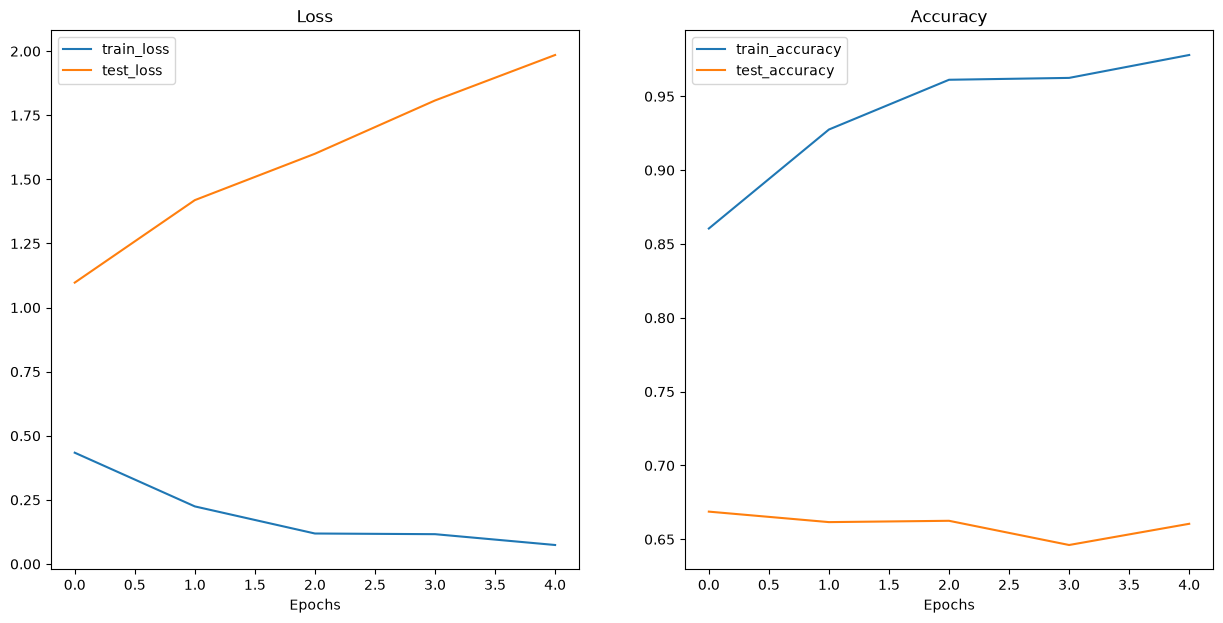

In [15]:
from helper_functions import plot_loss_curves
plot_loss_curves(results)